<a href="https://colab.research.google.com/github/saradom11/Simulaci-n-I/blob/main/Ejercicio_Flecha_y_cojinete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Flecha y cojinete:**

<img src="https://lh3.googleusercontent.com/drive-storage/AJQWtBOZzXxhtU8nOao-v8hBszBuzGFg5OycdmtWyCEujBEcrlJFk2694uSdHVMJov8gSSiYnfxw0SwlHJaXvUdV9MOTDUQLAXiXRQ4ewKRpLA9q7Nu9QA=w1852-h870?auditContext=forDisplay" width="600" height="300">

In [1]:
#Importamos librerias:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import math

###*Solución analítica:*

Como $X_1$ y $X_2$ son variables aleatorias normales independientes, su diferencia \(D\) también sigue una distribución normal.

Flecha: $$ X_1 \sim \mathcal{N}(\mu_1=1.5, \sigma_1^2=0.0016) \rightarrow \sigma= 0.04$$
Cojinete: $$ X_2 \sim \mathcal{N}(\mu_1=1.48, \sigma_1^2=0.0009) \rightarrow \sigma= 0.03$$
D:
$$D\sim \mathcal{N}(\mu_D, \sigma_D^2)$$

In [2]:
#Datos para el inciso a)
mu_1 , sigma_1 = 1.5, np.sqrt(0.0016)
mu_2 , sigma_2 = 1.48, np.sqrt(0.0009)
#Calculo de D
mu_d = mu_1 - mu_2
sigma_d = np.sqrt(sigma_1**2 + sigma_2**2)
#Calculo la probabilidad (P(D>0))
z=(0-mu_d)/sigma_d
prob_inter=1-norm.cdf(z)

#Imprimimos el resultado del inciso a):
print(f"mu_d: {mu_d}")
print(f"sigma_d: {sigma_d}")
print(f"Probabilidad de interferencias: {1-prob_inter}")

#Datos para el inciso b)
p=prob_inter
z_alpha=1.96
Error=0.01
#Calculos para el numero de simulaciones necesarias
n= (z_alpha**2*p*(1-p))/(Error**2)

#Imprimos el resultado del inciso b):
print(f"Numero de simulaciones necesarias: {n}")

mu_d: 0.020000000000000018
sigma_d: 0.05
Probabilidad de interferencias: 0.3445782583896757
Numero de simulaciones necesarias: 8676.026263132599


##*Solución por simulación:*

Resolviendo por simulación por el **método de Monte Carlo**

In [3]:
n=10000 #Número de simulaciones
X_1=np.random.normal(mu_1,sigma_1,n) #Generamos X_1 y X_2
X_2=np.random.normal(mu_2,sigma_2,n)
interferencia= X_2>X_1
prob_simulada=np.mean(interferencia)
#Resultado del inciso a)
print(f"Probabilidad de interferencias: {prob_simulada}")

Probabilidad de interferencias: 0.3542


(array([0.03820097, 0.01273366, 0.        , 0.03820097, 0.0891356 ,
        0.07640194, 0.14007022, 0.14007022, 0.24193947, 0.30560775,
        0.53481357, 0.86588864, 1.13329542, 1.43890318, 2.25385719,
        2.75046979, 3.52722284, 4.02383544, 4.60958363, 5.75561271,
        6.34136091, 7.02897836, 7.88213334, 7.15631492, 8.26414303,
        7.69112849, 7.37278708, 6.95257642, 6.63423501, 6.41776285,
        5.56460787, 4.43131244, 3.93469984, 3.42535358, 2.72500248,
        2.15198794, 1.51530512, 1.22243102, 0.81495401, 0.67488379,
        0.39474335, 0.33107507, 0.14007022, 0.2037385 , 0.02546731,
        0.01273366, 0.02546731, 0.01273366, 0.        , 0.01273366]),
 array([-0.17653338, -0.16868018, -0.16082698, -0.15297377, -0.14512057,
        -0.13726736, -0.12941416, -0.12156096, -0.11370775, -0.10585455,
        -0.09800135, -0.09014814, -0.08229494, -0.07444173, -0.06658853,
        -0.05873533, -0.05088212, -0.04302892, -0.03517571, -0.02732251,
        -0.01946931, -0.01

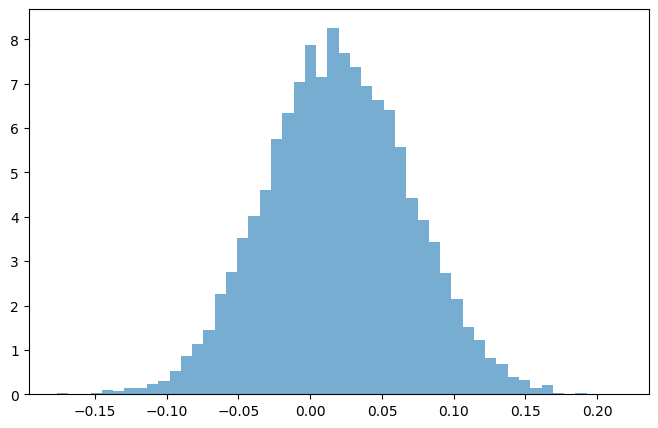

In [4]:
D= X_1-X_2
plt.figure(figsize=(8,5))
plt.hist(D, bins=50, density=True, alpha=0.6, label='Simulado')